<a href="https://colab.research.google.com/github/MRaynardAlif/DecisionTree-RandomForestTutorial/blob/main/RandomForest2_AC_AnomalyDetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### MUHAMAD RAYNARD ALIF - 20523167

## Part 1

1.  Import Libraries that we need.
2.  Load the Dataset.
3.  Time Feature Engineering (for timestamp)
4.  Encode Categorical Features, because we have more than 1 unit type.
5.  Split the dataset into train and test data.
6.  Hyperparameter Tuning with GridSearchCV.
7.  Train the model using the best Hyperparameter.
8.  Show the Classification Report.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# === Step 1: Load the Dataset ===
data = pd.read_csv('/content/drive/MyDrive/HVAC_DATASET/MeasurementData/SyntheticDataset/MainTrainingDataset/SyntheticTrainingDataset.csv')

# === Step 2: Parse Time and Extract Time-Based Features ===
print("Extracting time-based features...")
data['Time'] = pd.to_datetime(data['Time'])

# Add engineered time features
data['Hour'] = data['Time'].dt.hour
data['Minute'] = data['Time'].dt.minute
data['DayOfWeek'] = data['Time'].dt.dayofweek


# === Step 3: Select Features and Target ===
features = data[['Current (A)', 'Voltage (V)', 'Wattage (W)', 'Temperature Indoor (°C)',
                 'Temperature Outdoor (°C)', 'Set Point (°C)', 'Alpha (°C)', 'Supply (°C)',
                 'Return (°C)', 'Delta (°C)', 'Beta (°C)', 'Cycle', 'Unit',
                 'Hour', 'Minute', 'DayOfWeek']]
labels = data['Condition']

# === Step 4: One-Hot Encode Categorical Features ===
features = pd.get_dummies(features, columns=['Unit', 'Cycle'])

# === Step 5: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# === Step 6: Train the RandomForest Model with Best Parameters ===
print("Tuning hyperparameters...")
param_grid = {
    'n_estimators': [250, 300],
    'max_depth': [None],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 3]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Hyperparameter tuning completed.")

print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

# === Step 7: Evaluate the Model ===
# Train the Model with Best Parameters
print("Training the model with best parameters...")
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
print("Training completed.")

# Evaluate the Model
print("Evaluating the model...")
y_pred = best_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Evaluation completed.")

Extracting time-based features...
Tuning hyperparameters...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Hyperparameter tuning completed.
Best parameters found by GridSearchCV:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Training the model with best parameters...
Training completed.
Evaluating the model...
Classification Report:
                precision    recall  f1-score   support

     ABNORMAL       0.98      0.98      0.98     24299
MAINTENANCE 1       0.98      0.98      0.98     24188
MAINTENANCE 2       0.99      0.99      0.99     24123
       NORMAL       0.98      1.00      0.99     24348
    TROUBLE 1       0.98      0.99      0.99     24035
    TROUBLE 2       0.99      0.98      0.99     24080
    TROUBLE 3       1.00      0.98      0.99     24271

     accuracy                           0.99    169344
    macro avg       0.99      0.99      0.99    169344
 weighted avg       0.99      0.99      0.99    169344

E

##  Part 2

Visualize Cross-validation Scores, Learning Curve, Validation Curve, Feature Importance, Confusion Matrix.

Cross-Validation Scores: [0.85751842 0.83617489 0.91431406]
Mean CV Score: 0.8693357898715042
Standard Deviation of CV Scores: 0.03297645791354598


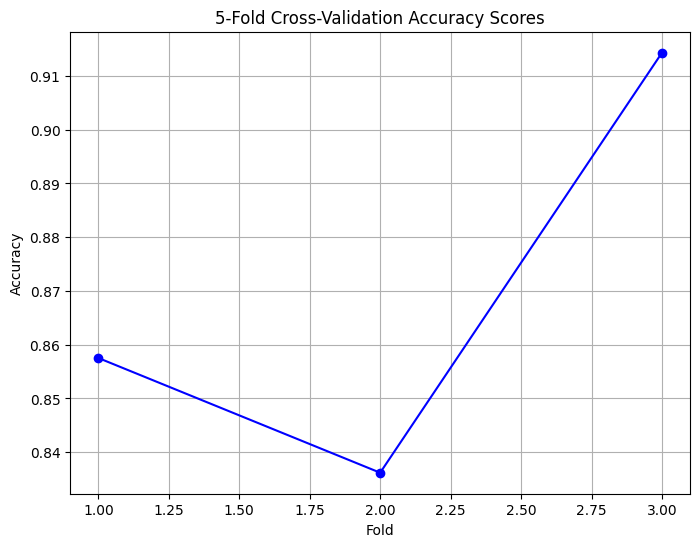

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Perform 3-fold cross-validation
cv_scores = cross_val_score(best_model, features, labels, cv=3, n_jobs=-1)

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))
print("Standard Deviation of CV Scores:", np.std(cv_scores))

# Plot the cross-validation results
plt.figure(figsize=(8, 6))
plt.plot(range(1, 4), cv_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Accuracy Scores')
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


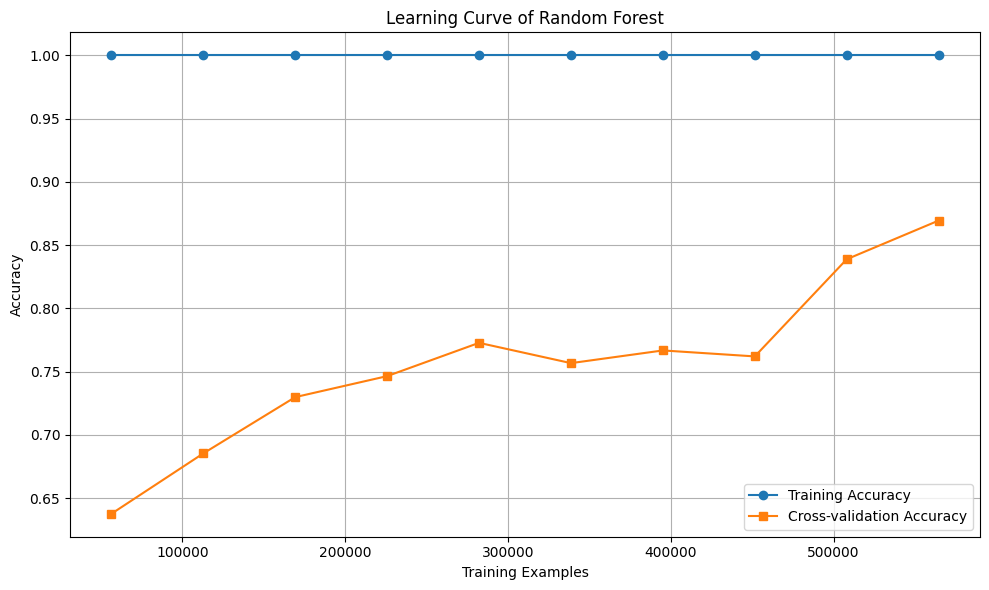

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Plot Learning Curve
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    estimator=best_model,
    X=features,
    y=labels,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1  # Use all available CPU cores
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores_lc, axis=1), label='Training Accuracy', marker='o')
plt.plot(train_sizes, np.mean(test_scores_lc, axis=1), label='Cross-validation Accuracy', marker='s')
plt.title('Learning Curve of Random Forest')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

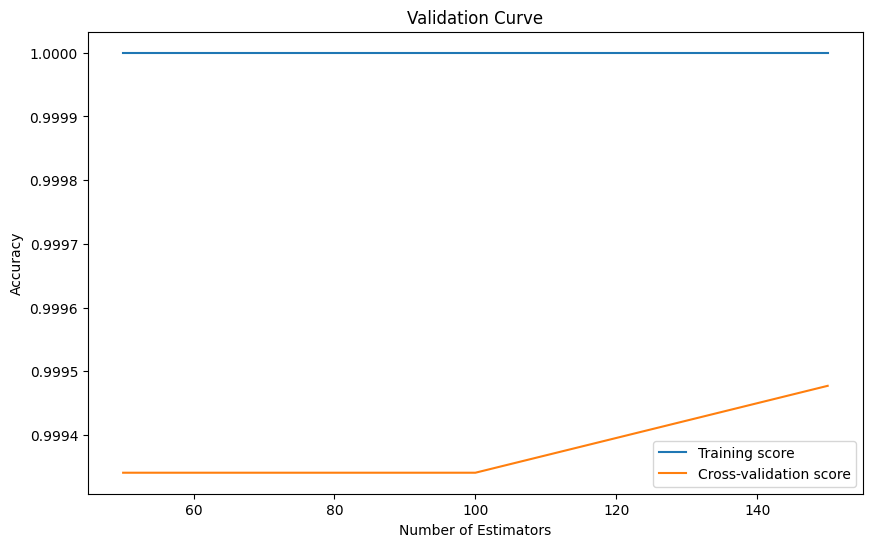

In [ ]:
# Plot Validation Curve (e.g., for n_estimators)
param_range = [50, 100, 150, 200, 250]
train_scores, test_scores = validation_curve(best_model, X_train, y_train,
                                             param_name="n_estimators", param_range=param_range,
                                             cv=3, scoring="accuracy")
plt.figure(figsize=(10, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
plt.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.title('Validation Curve')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

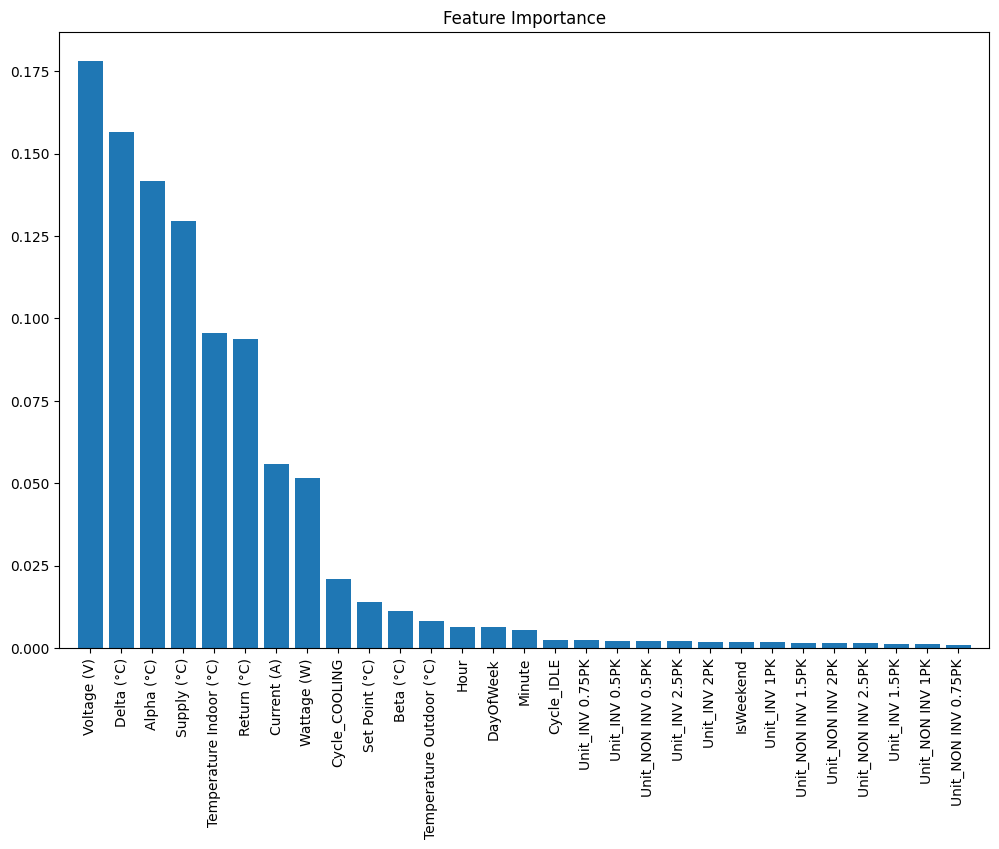

In [ ]:
# Plot Feature Importance
feature_importances = best_model.feature_importances_
features_names = X_train.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(12, 8))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), [features_names[i] for i in indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

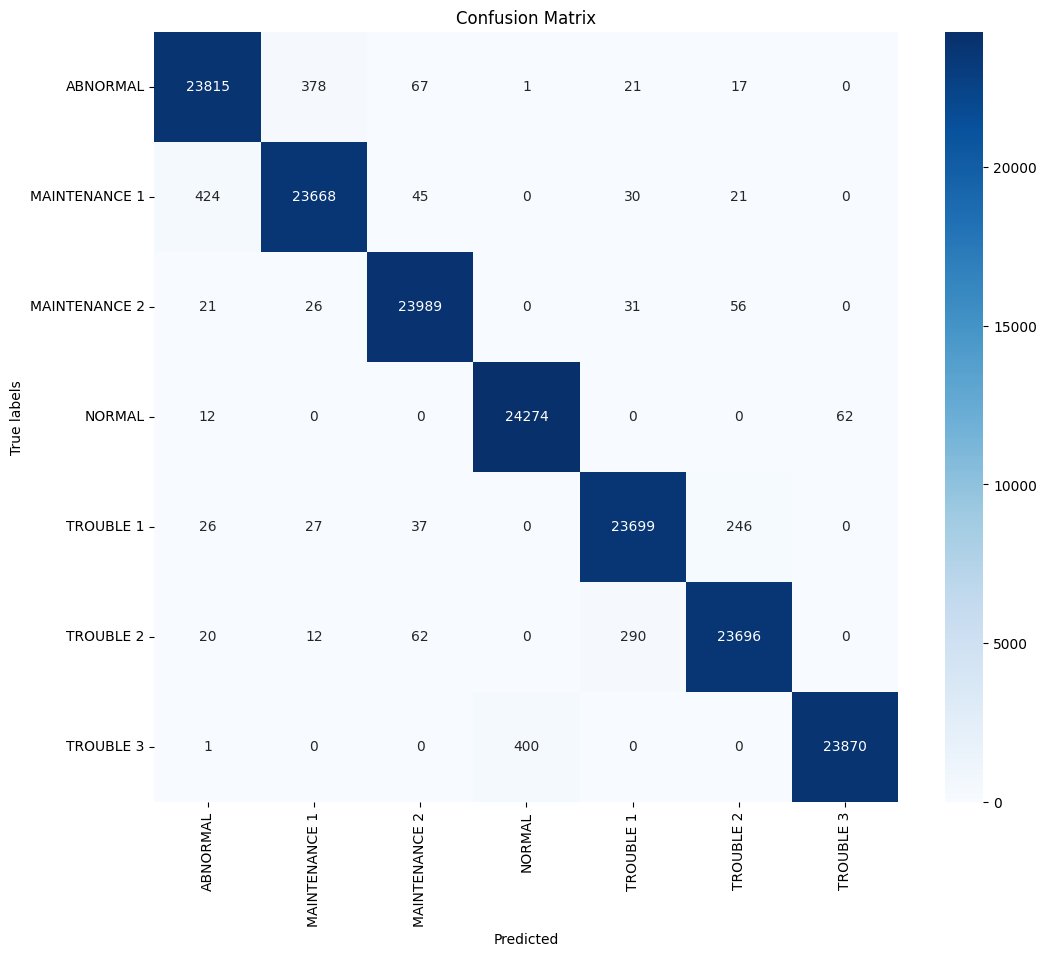

In [ ]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix for comparing the model's predictions against the true labels
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True labels')
plt.show()
